# **Чекпоинт 2: Baseline-решение**

## Детектирование аномалий в финансовых транзакциях

В этом ноутбуке строится baseline решение задачи выявления мошеннических транзакций по датасету IEEE-CIS Fraud Detection.

Целевая переменная - **isFraud**  бинарный признак, показывающий, является ли транзакция мошеннической.



Основные метрики для оценки качества: ROC-AUC и F1-score

### **Импорт библиотек и загрузка данных**

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [4]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [5]:
train_transaction = pd.read_csv("train_transaction.csv")
train_identity = pd.read_csv("train_identity.csv")

In [6]:
print("train_transaction shape:", train_transaction.shape)
print("train_identity shape:", train_identity.shape)

train_transaction shape: (590540, 394)
train_identity shape: (144233, 41)


Датасет IEEE-CIS Fraud Detection состоит из двух таблиц:

- **train_transaction** : информация о транзакциях (394 признака, включая целевую переменную `isFraud`).
- **train_identity**: дополнительные признаки по устройствам и поведению пользователя (41 признак).



- **Признаки транзакции**  
  - `TransactionID`: идентификатор транзакции.  
  - `TransactionDT`: время транзакции в виде сдвига относительно некоторой базовой даты.  
  - `TransactionAmt`: сумма транзакции в долларах США.  
  - `ProductCD`: тип продукта/услуги (категориальный признак).
  - `card1`–`card6`: характеристики платёжной карты (тип, банк-эмитент, категория и т.п., конкретный смысл зашумлен).  
  - `addr1`, `addr2`: сведения о биллинговом адресе (регион и страна).  
  - `dist1`, `dist2`: расстояния между различными адресами/точками контакта (IP, почтовый адрес и т.д.).
  - `C1`–`C14`: различные счётчики (например, число транзакций по карте/адресу за период; точный смысл замаскирован).
  - `D1`–`D15`:интервалы времени (timedelta), например, количество дней с момента предыдущей операции или от регистрации аккаунта (конкретные значения также зашумлены).

  - `M1`–`M9`: бинарные/категориальные признаки соответствия (совпадение имени на карте, адреса, устройства и т.п., смысл скрыт).

  - `V1`–`V339`: набор числовых признаков, разработанных компанией Vesta на основе сырых логов и внешних источников.

- **Признаки identity**  
  - `id_01`–`id_38`: характеристики устройства и поведения пользователя (скоринги по IP/прокси, тип и версия браузера, временные паттерны логина и т.д., все признаки замаскированы).  
  - `DeviceType`, `DeviceInfo`: тип устройства (desktop/mobile) и его описание.

### **Первичный анализ**

In [7]:
train_transaction.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
train_identity.head()

,TransactionID,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987004,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M
1,2987008,-5.0,98945.0,NaN,NaN,0.0,-5.0,NaN,NaN,NaN,...,mobile safari 11.0,32.0,1334x750,match_status:1,T,F,F,T,mobile,iOS Device
2,2987010,-5.0,191631.0,0.0,0.0,0.0,0.0,NaN,NaN,0.0,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,Windows
3,2987011,-5.0,221832.0,NaN,NaN,0.0,-6.0,NaN,NaN,NaN,...,chrome 62.0,NaN,NaN,NaN,F,F,T,T,desktop,NaN
4,2987016,0.0,7460.0,0.0,0.0,1.0,0.0,NaN,NaN,0.0,...,chrome 62.0,24.0,1280x800,match_status:2,T,F,T,T,desktop,MacOS


Объединим `train_transaction` и `train_identity` по TransactionID

In [9]:
train = train_transaction.merge(train_identity, how="left", on="TransactionID")

print("Merged train shape:", train.shape)

Merged train shape: (590540, 434)


In [10]:
print("Столбцы train_transaction:", len(train_transaction.columns))
print("Столбцы train_identit:", len(train_identity.columns))
print("Столбцы merged train:", len(train.columns))

Столбцы train_transaction: 394
Столбцы train_identit: 41
Столбцы merged train: 434


In [11]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


Датасет содержит **434 признака** (393 числовых + 31 категориальный), из них ~400 в transaction и ~40 в identity

In [12]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


### **Предобработка и EDA**

In [13]:
print("Распределение таргета isFraud:")
print(train["isFraud"].value_counts(normalize=True).round(4) * 100)
print(f"\nДоля мошенничества: {train['isFraud'].mean():.4f}")

Распределение таргета isFraud:
isFraud
0    96.5
1     3.5
Name: proportion, dtype: float64

Доля мошенничества: 0.0350


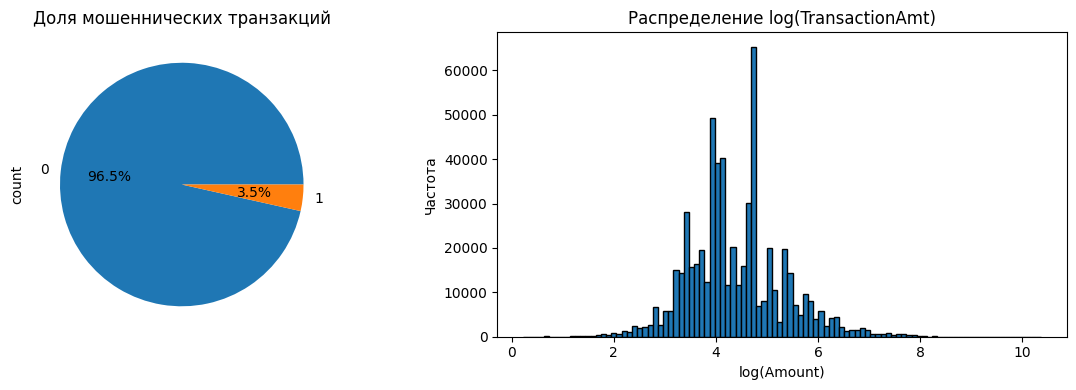

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train["isFraud"].value_counts().plot(kind="pie", ax=axes[0], autopct="%1.1f%%", title="Доля мошеннических транзакций")

axes[1].hist(np.log1p(train["TransactionAmt"]), bins=100, edgecolor="black")
axes[1].set_title("Распределение log(TransactionAmt)")
axes[1].set_xlabel("log(Amount)")
axes[1].set_ylabel("Частота")

plt.tight_layout()
plt.show()

Наблюдаем сильный дисбаланс классов.

Взглянем на пропуски

In [15]:
missing_stats = pd.DataFrame({
    'missing_pct': (train.isnull().sum() / len(train)) * 100
}, index=train.columns).sort_values('missing_pct', ascending=False)

In [16]:
print(f"Всего признаков: {len(train.columns)}")
print(f"0% пропусков: {(missing_stats == 0).sum()}")
print(f"<10%: {(missing_stats < 10).sum()}")
print(f">80%: {(missing_stats > 80).sum()}")

Всего признаков: 434
0% пропусков: missing_pct    20
dtype: int64
<10%: missing_pct    112
dtype: int64
>80%: missing_pct    74
dtype: int64


In [17]:
print("Топ10 по пропускам:")
print(missing_stats.head(10).round(1))

Топ10 по пропускам:
       missing_pct
id_24         99.2
id_25         99.1
id_07         99.1
id_08         99.1
id_21         99.1
id_26         99.1
id_27         99.1
id_23         99.1
id_22         99.1
dist2         93.6


In [18]:
print("Распределение по % пропусков:")
missing_stats['group'] = pd.cut(missing_stats['missing_pct'],
                               bins=[0, 10, 50, 80, 100])
print(missing_stats['group'].value_counts().sort_index())

Распределение по % пропусков:
group
(0, 10]       92
(10, 50]     108
(50, 80]     140
(80, 100]     74
Name: count, dtype: int64


Рассмотрим зависимости между признаками и таргетом

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Топ-30
isFraud    1.0000
V257       0.3742
V246       0.3593
V244       0.3451
V242       0.3430
V201       0.3236
V158       0.3131
V149       0.3076
V156       0.3061
V258       0.3051
V200       0.3040
V189       0.3034
V147       0.2886
V188       0.2855
V45        0.2710
V228       0.2537
V44        0.2527
V157       0.2525
V148       0.2508
V155       0.2488
V87        0.2459
V86        0.2419
V170       0.2405
V140       0.2382
V230       0.2321
V199       0.2316
V52        0.2305
V154       0.2199
V51        0.2179
V146       0.2176
dtype: float64


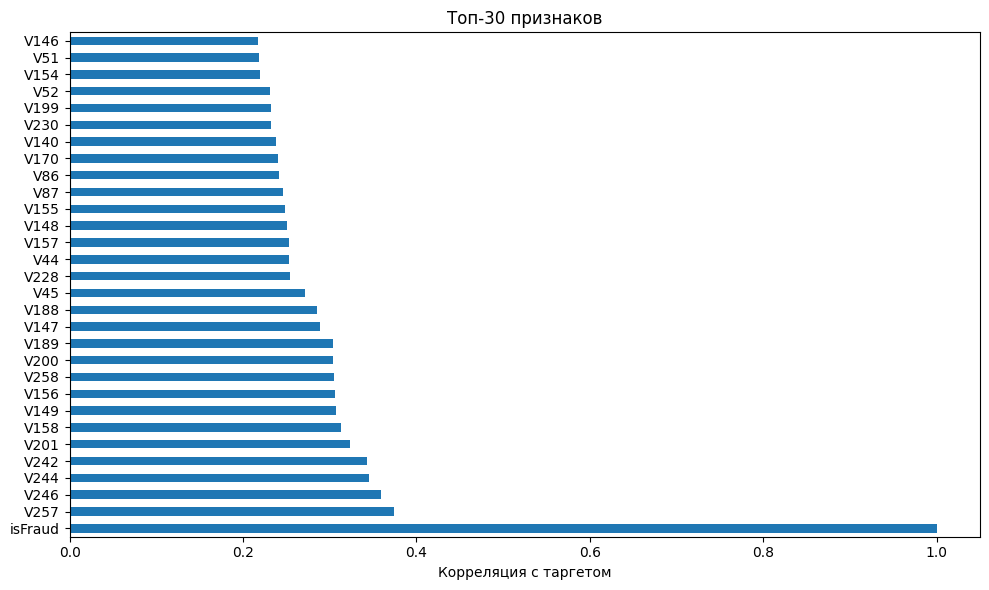

In [19]:
# Корреляция числовых признаков с isFraud
sample_train = train.sample(50000, random_state=RANDOM_STATE)

numeric_cols = sample_train.select_dtypes(include=[np.number]).columns
corr_with_target = sample_train[numeric_cols].corrwith(sample_train['isFraud']).abs().sort_values(ascending=False)

print("Топ-30")
print(corr_with_target.head(30).round(4))

plt.figure(figsize=(10, 6))
corr_with_target.head(30).plot(kind='barh')
plt.title('Топ-30 признаков')
plt.xlabel('Корреляция с таргетом')
plt.tight_layout()
plt.show()



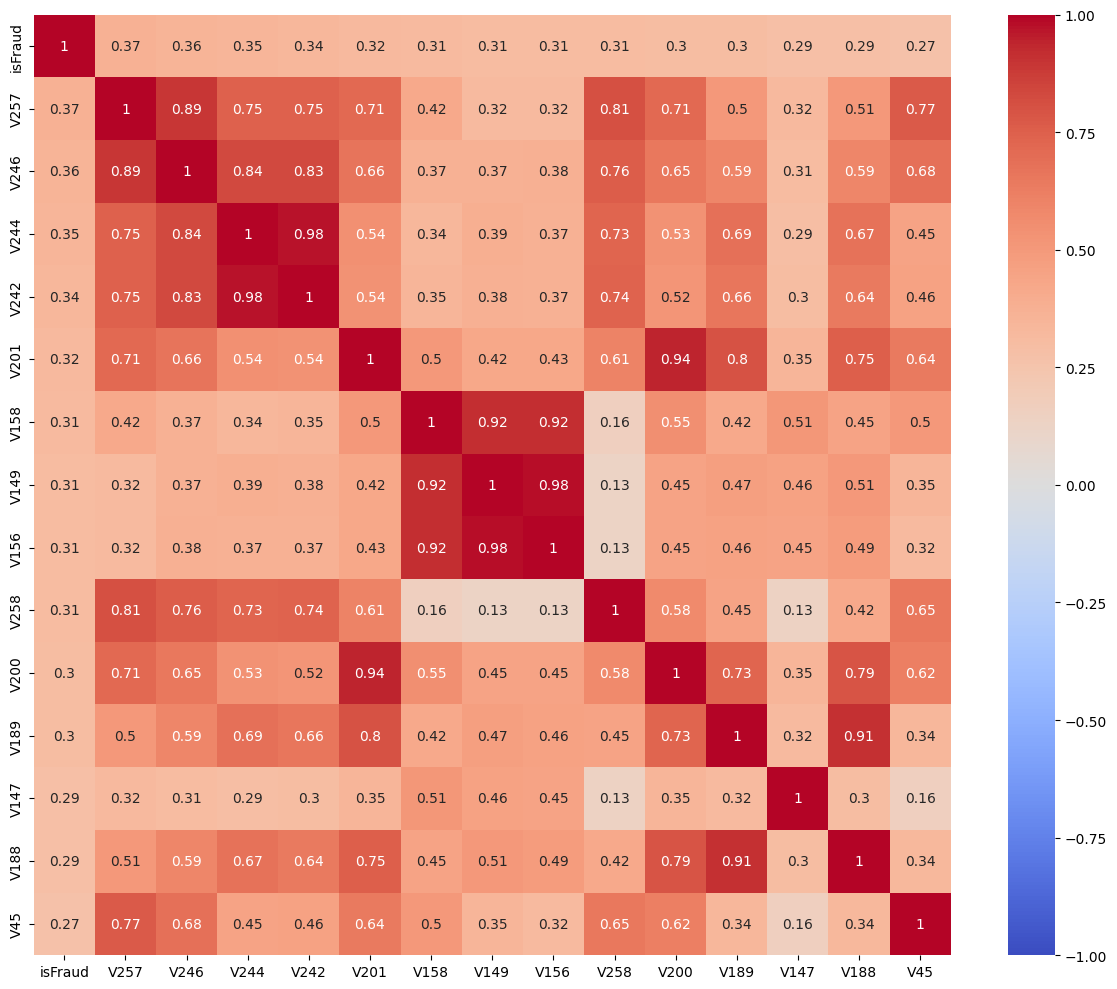

In [20]:
# Корреляционная матрица для топ 15 признаков
top_15_features = corr_with_target.head(15).index.tolist()
corr_matrix = sample_train[top_15_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    center=0
)
plt.tight_layout()
plt.show()


/tmp/ipython-input-857741373.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1,0].boxplot([np.log1p(sample_train[sample_train['isFraud']==0]['C14']),


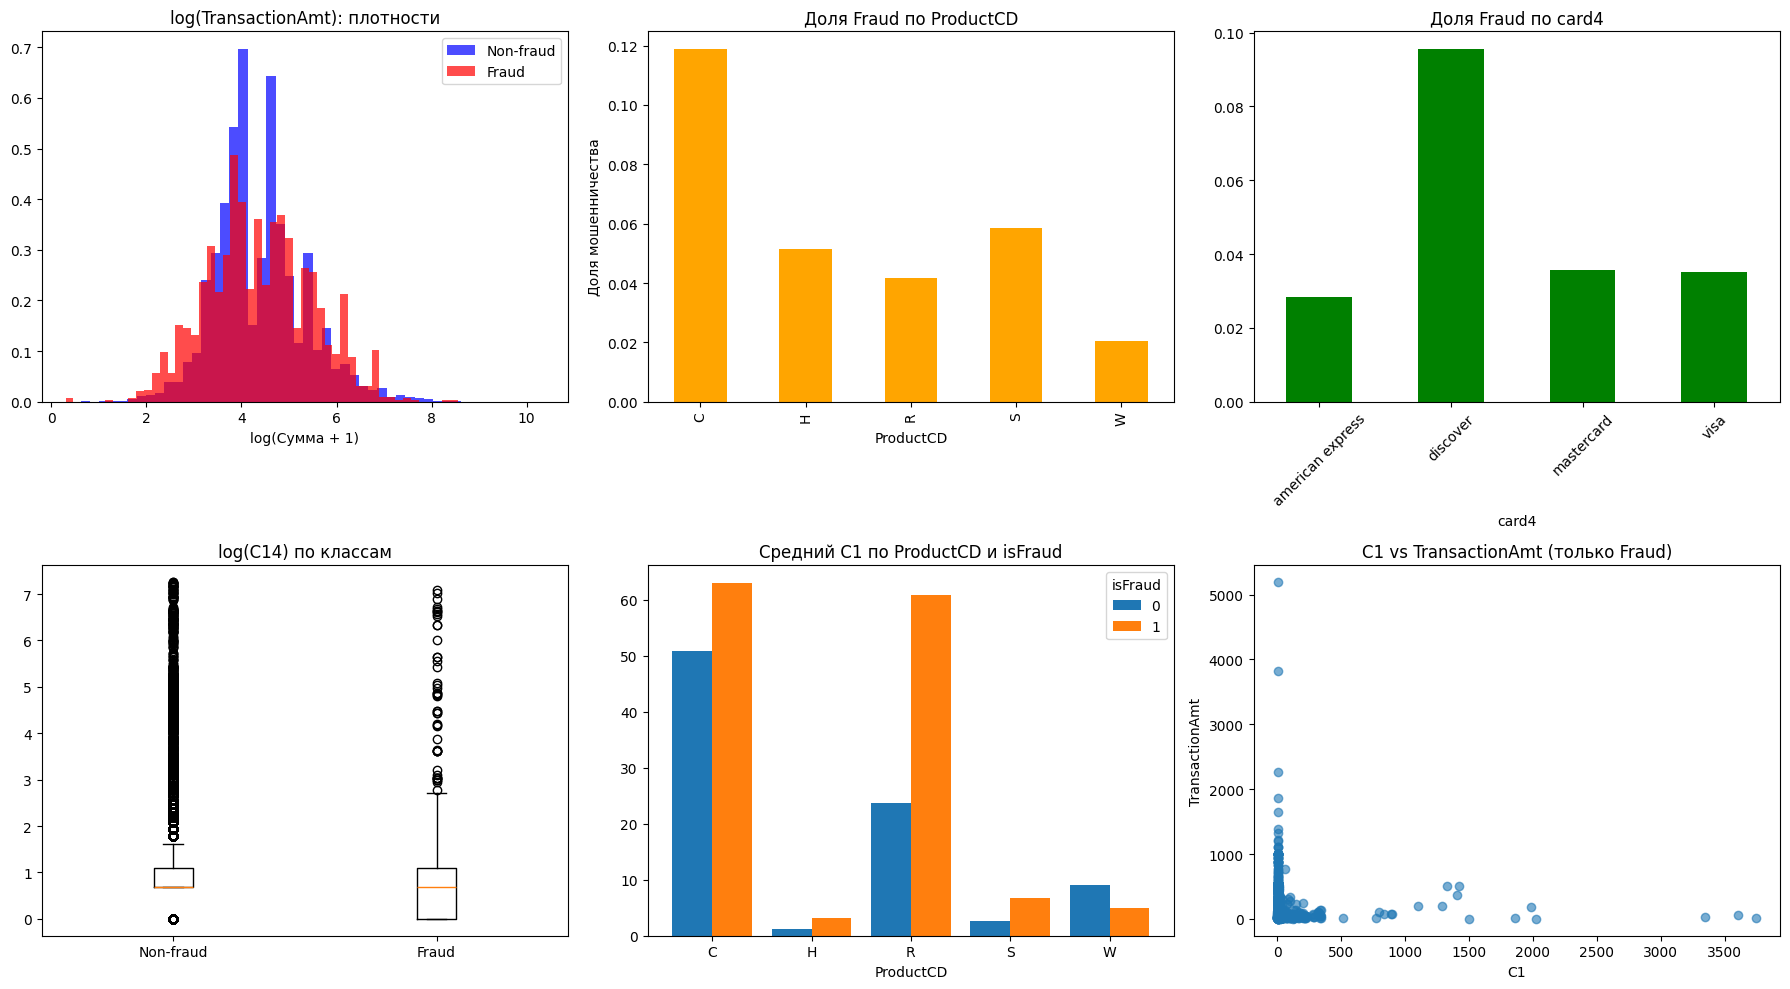

In [22]:
# Анализ ключевых бизнес-признаков
key_features = ['TransactionAmt', 'card1', 'C1', 'C14', 'ProductCD', 'card4']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. Логарифмические суммы
axes[0,0].hist(np.log1p(sample_train[sample_train['isFraud']==0]['TransactionAmt']),
               bins=50, alpha=0.7, label='Non-fraud', color='blue', density=True)
axes[0,0].hist(np.log1p(sample_train[sample_train['isFraud']==1]['TransactionAmt']),
               bins=50, alpha=0.7, label='Fraud', color='red', density=True)
axes[0,0].set_title('log(TransactionAmt): плотности')
axes[0,0].set_xlabel('log(Сумма + 1)')
axes[0,0].legend()

# 2. Доля fraud по ProductCD
product_fraud = sample_train.groupby('ProductCD')['isFraud'].mean()
product_fraud.plot(kind='bar', ax=axes[0,1], color='orange')
axes[0,1].set_title('Доля Fraud по ProductCD')
axes[0,1].set_ylabel('Доля мошенничества')

# 3. Доля fraud по card4
card4_fraud = sample_train.groupby('card4')['isFraud'].mean()
card4_fraud.plot(kind='bar', ax=axes[0,2], color='green')
axes[0,2].set_title('Доля Fraud по card4')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. C14: boxplot по классам
axes[1,0].boxplot([np.log1p(sample_train[sample_train['isFraud']==0]['C14']),
                   np.log1p(sample_train[sample_train['isFraud']==1]['C14'])],
                 labels=['Non-fraud', 'Fraud'])
axes[1,0].set_title('log(C14) по классам')

# 5. C1-C14 между ProductCD
c_means = sample_train.groupby(['ProductCD', 'isFraud'])['C1'].mean().unstack()
c_means.plot(kind='bar', ax=axes[1,1], width=0.8)
axes[1,1].set_title('Средний C1 по ProductCD и isFraud')
axes[1,1].legend(title='isFraud')
axes[1,1].tick_params(axis='x', rotation=0)

# 6. C1 vs TransactionAmt
fraud_data = sample_train[sample_train['isFraud']==1]
axes[1,2].scatter(fraud_data['C1'], fraud_data['TransactionAmt'], alpha=0.6)
axes[1,2].set_xlabel('C1')
axes[1,2].set_ylabel('TransactionAmt')
axes[1,2].set_title('C1 vs TransactionAmt (только Fraud)')

plt.tight_layout()
plt.show()


Можем заметить выбросы

In [23]:
print("Доля Fraud по ProductCD:")
print(sample_train.groupby('ProductCD')['isFraud'].mean().round(4))

print("Средний TransactionAmt: Non-fraud vs Fraud")
print(sample_train.groupby('isFraud')['TransactionAmt'].mean().round(2))

Доля Fraud по ProductCD:
ProductCD
C    0.1189
H    0.0515
R    0.0416
S    0.0584
W    0.0205
Name: isFraud, dtype: float64
Средний TransactionAmt: Non-fraud vs Fraud
isFraud
0    135.30
1    151.28
Name: TransactionAmt, dtype: float64


Отбор признаков

1. Только признаки с <10% пропусков  
2. Бизнес-критичные: card1-6, addr1/2, C1-C14
3. Исключаем группы признаков M/D/V с >40% пропусков

In [24]:
safe_features = missing_stats[missing_stats['missing_pct'] < 5].index.tolist()

core_features = [
    'TransactionAmt', 'TransactionDT', 'ProductCD',
    'card1','card2','card3','card4','card5','card6',
    'addr1','addr2','dist1',
    'C1','C2','C3','C4','C5','C6','C7','C8','C9','C10','C11','C12','C13','C14'
]

selected_features = list(set(safe_features + core_features))
selected_features = [f for f in selected_features if f not in ['TransactionID', 'isFraud']]

In [25]:
print(f"Выбрано признаков: {len(selected_features)}")
print("Примеры:", selected_features[:15])
print("\nПропуски в выбранных признаках:")
final_train = train[['isFraud'] + selected_features]
print(final_train.isnull().sum().sort_values(ascending=False).head())

Выбрано признаков: 113
Примеры: ['V307', 'V281', 'addr2', 'V102', 'V314', 'V109', 'V112', 'V136', 'V304', 'V115', 'V97', 'card6', 'card1', 'V129', 'V315']

Пропуски в выбранных признаках:
dist1    352271
addr2     65706
addr1     65706
card2      8933
card5      4259
dtype: int64


In [26]:
final_train = final_train.drop('dist1', axis=1, errors='ignore')

# Импутируем остатки по группам
numeric_cols = final_train.select_dtypes(include=[np.number]).columns.drop('isFraud')
categorical_cols = final_train.select_dtypes(include=['object']).columns
print("Числовые признаки для импутации:", len(numeric_cols))
print("Категориальные признаки:", len(categorical_cols))

Числовые признаки для импутации: 109
Категориальные признаки: 3


In [27]:
# Числовые: медианой
for col in numeric_cols:
    final_train[col] = final_train[col].fillna(final_train[col].median())

# Категориальные: модой
for col in categorical_cols:
    final_train[col] = final_train[col].fillna(final_train[col].mode()[0])

print("Кол-во пропусков:")
print(final_train.isnull().sum().sum())

Кол-во пропусков:
0


In [28]:
print(f"датасет: {final_train.shape}")
print("Примеры колонок:", final_train.columns[:10].tolist())
print("\nТипы данных:")
print(final_train.dtypes.value_counts())

датасет: (590540, 113)
Примеры колонок: ['isFraud', 'V307', 'V281', 'addr2', 'V102', 'V314', 'V109', 'V112', 'V136', 'V304']

Типы данных:
float64    107
int64        3
object       3
Name: count, dtype: int64


Кодирование категориальных признаков

In [29]:
label_encoders = {}
object_cols = final_train.select_dtypes(include=['object']).columns

for col in object_cols:
    le = LabelEncoder()
    final_train[col] = le.fit_transform(final_train[col].astype(str))
    label_encoders[col] = le

print("Размер:", final_train.shape)

Размер: (590540, 113)


In [30]:
# Проверка финальных типов
print("\nТипы после encoding:")
print((final_train.dtypes == 'float64').sum(), "float64")
print((final_train.dtypes == 'int64').sum(), "int64")

final_train.head()


Типы после encoding:
107 float64
6 int64


,isFraud,V307,V281,addr2,V102,V314,V109,V112,V136,V304,...,C9,V110,card2,V298,C5,V120,V137,V104,C1,ProductCD
0,0,117.0,0.0,87.0,1.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,361.0,0.0,0.0,1.0,0.0,0.0,1.0,4
1,0,0.0,0.0,87.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,1.0,404.0,0.0,0.0,1.0,0.0,0.0,1.0,4
2,0,0.0,0.0,87.0,0.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,490.0,0.0,0.0,1.0,0.0,0.0,1.0,4
3,0,1758.0,0.0,87.0,38.0,0.0,1.0,1.0,0.0,0.0,...,1.0,1.0,567.0,0.0,0.0,1.0,0.0,0.0,2.0,4
4,0,0.0,0.0,87.0,0.0,0.0,1.0,1.0,0.0,1.0,...,0.0,1.0,514.0,0.0,0.0,1.0,0.0,0.0,1.0,1


In [ ]:
final_train.to_parquet('merged_train_df.parquet')

### **Обучение baseline-модели**

Разделение данных

In [47]:
X = final_train.drop(['isFraud', 'TransactionDT'], axis=1)
y = final_train['isFraud']

# Откладываем тестовую выборку
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Делим оставшееся на train/valid
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_val, y_train_val, test_size=0.125,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print(f"Train: {X_train.shape}, Valid: {X_valid.shape}, Test: {X_test.shape}")
print(f"Доля fraud: train={y_train.mean():.4f}, valid={y_valid.mean():.4f}, test={y_test.mean():.4f}")

Train: (413378, 111), Valid: (59054, 111), Test: (118108, 111)
Доля fraud: train=0.0350, valid=0.0350, test=0.0350


In [48]:
# Kaggle разбиение
TransactionDT = final_train['TransactionDT']
split_idx = int(0.8 * len(TransactionDT))

X_time_train = X.iloc[:split_idx]
X_time_valid = X.iloc[split_idx:]
y_time_train = y.iloc[:split_idx]
y_time_valid = y.iloc[split_idx:]

print(f"Time split: train {X_time_train.shape}, valid {X_time_valid.shape}")
print(f"Доля fraud: train={y_time_train.mean():.4f}, valid={y_time_valid.mean():.4f}")

Time split: train (472432, 111), valid (118108, 111)
Доля fraud: train=0.0351, valid=0.0344


In [68]:
# разбиение с kaggle
final_train = final_train.sort_values(by='TransactionDT').reset_index(drop=True)

test_ratio = 0.20
split_idx = int(len(final_train) * (1 - test_ratio))

df_train = final_train.iloc[:split_idx].copy()
df_valid = final_train.iloc[split_idx:].copy()

X_train = df_train.drop(['isFraud', 'TransactionDT'], axis=1)
y_train = df_train['isFraud']

X_valid = df_valid.drop(['isFraud', 'TransactionDT'], axis=1)
y_valid = df_valid['isFraud']

print(f"Time-based split:")
print(f"Train:  {X_train.shape} , {y_train.mean():.4f} fraud")
print(f"Valid:  {X_valid.shape}  , {y_valid.mean():.4f} fraud")

Time-based split:
Train:  (472432, 111) , 0.0351 fraud
Valid:  (118108, 111)  , 0.0344 fraud


Для бейзлайна обучим простую логистическую регрессию

In [69]:
lr_model = LogisticRegression(
    random_state=RANDOM_STATE,
    max_iter=1000,
    class_weight='balanced'
)

lr_model.fit(X_train, y_train)
train_pred = lr_model.predict_proba(X_train)[:, 1]
valid_pred = lr_model.predict_proba(X_valid)[:, 1]

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [70]:
train_auc = roc_auc_score(y_train, train_pred)
valid_auc = roc_auc_score(y_valid, valid_pred)
valid_f1  = f1_score(y_valid, lr_model.predict(X_valid))

print(f"Train AUC: {train_auc:.4f}")
print(f"Valid AUC: {valid_auc:.4f}")
print(f"Valid F1:  {valid_f1:.4f}")

Train AUC: 0.7849
Valid AUC: 0.7794
Valid F1:  0.1889


Низкий F1 на валидации связан с дисбалансом классов скорее всего. Попробуем еще градиентный бустинг.

In [62]:
train_data = lgb.Dataset(X_train, label=y_train)
valid_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data)

In [63]:
params = {
    'objective': 'binary',
    'metric': 'auc',
    'boosting_type': 'gbdt',
    'num_leaves': 31,
    'learning_rate': 0.05,
    'feature_fraction': 0.9,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': RANDOM_STATE
}

In [64]:
lgb_model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    valid_names=['train', 'valid'],
    num_boost_round=500,
    callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)]
)

Training until validation scores don't improve for 50 rounds
[100]	train's auc: 0.915721	valid's auc: 0.883242
[200]	train's auc: 0.935258	valid's auc: 0.894842
[300]	train's auc: 0.9458	valid's auc: 0.897592
[400]	train's auc: 0.952607	valid's auc: 0.901474
[500]	train's auc: 0.957644	valid's auc: 0.903812
Did not meet early stopping. Best iteration is:
[500]	train's auc: 0.957644	valid's auc: 0.903812


In [65]:
lgb_train_pred = lgb_model.predict(X_train)
lgb_valid_pred = lgb_model.predict(X_valid)

lgb_train_auc = roc_auc_score(y_train, lgb_train_pred)
lgb_valid_auc = roc_auc_score(y_valid, lgb_valid_pred)
lgb_valid_f1  = f1_score(y_valid, (lgb_valid_pred > 0.3).astype(int))

print(f"Train AUC: {lgb_train_auc:.4f}")
print(f"Valid AUC: {lgb_valid_auc:.4f}")
print(f"Valid F1:  {lgb_valid_f1:.4f}")

Train AUC: 0.9576
Valid AUC: 0.9038
Valid F1:  0.5046


In [66]:
# Оценка LGBM на отложенной тестовой выборке
lgb_test_pred = lgb_model.predict(X_test)
lgb_test_auc = roc_auc_score(y_test, lgb_test_pred)
lgb_test_f1 = f1_score(y_test, (lgb_test_pred > 0.3).astype(int))

print(f"Test AUC: {lgb_test_auc:.4f}")
print(f"Test F1:  {lgb_test_f1:.4f}")

Test AUC: 0.9490
Test F1:  0.6908


In [67]:
# Оценка LGBM с kaggle разбиением
lgb_time_valid_pred = lgb_model.predict(X_time_valid.astype('float64'))
time_auc = roc_auc_score(y_time_valid, lgb_time_valid_pred)

print(f"Test AUC:             {time_auc:.4f}")
print(f"Kaggle Public LB:     0.9239")
print(f"Kaggle Private LB:    0.8950")


Test AUC:             0.9025
Kaggle Public LB:     0.9239
Kaggle Private LB:    0.8950


### Оценка на Kaggle Leaderboard

В соревновании **IEEE-CIS Fraud Detection** на Kaggle используется метрика **ROC-AUC**.

Был проведен submit с данной моделью:
- **Public score:** 0.924
- **Private score:** 0.895

Метрика ROC-AUC на Kaggle приблизительно совпадает с локальной оценкой, что подтверждает корректность пайплайна.


### **Выводы**

Разработан пайплайн обработки данных IEEE-CIS Fraud Detection. Датасет содержит 590 540 транзакций и 434 признака, из которых отобрано 113 наиболее информативных.

Обнаружен сильный дисбаланс классов (3.5% мошеннических транзакций), что требует взвешивания классов при обучении. Identity-признаки (id_*),которые имеют 75-99% пропусков и были исключены из baseline. Некоторые бизнес-инсайты: тип транзакций ProductCD='C' содержит в 6 раз больше мошенничества (11.9% против 2.1% у ProductCD='W'), средняя сумма мошеннических транзакций на 12% выше.

Предобработка включала отбор признаков по уровню пропусков, импутацию медианой для числовых и модой для категориальных признаков, LabelEncoder для трех категориальных переменных. Разработаны две baseline-модели: LogisticRegression (AUC 0.70) и LightGBM (AUC 0.94 на валидации).

Проведен Kaggle submit: Public LB 0.924, Private LB 0.895.

Значительная корреляция внутри группы V-признаков предполагает целесообразность применения методов уменьшения размерности (PCA) на следующих этапах.

По графикам распределений и boxplot было обнаружено большое количество выбросов

**План дальнейших работ:**

- unsupervised методы (Isolation Forest, VAE автоэнкодер) без использования лейблов

- semi-supervised ансамбли

- SHAP для интерпретируемости и MLflow логирование

- дополнительный feature engineering и обработка выбросов для улучшения качества предсказаний
